# Real Diffusers image U-Net: matched-noise steering

Install `.[diffusion,notebooks]`. An actual tiny Diffusers U-Net is trained briefly on 8x8 bars. Compare fixed-noise runs with a zero-strength control, selected-step intervention and random-direction control. This is unconditional image diffusion, not text-to-image or PolypSteer reproduction; brief training does not guarantee realistic samples.

Run all cells in a fresh kernel. The final cell records local runtime and kernel RSS.

In [1]:
import os, time, json, resource, sys
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["USE_TF"] = "0"
os.environ["WANDB_MODE"] = "disabled"
import torch, numpy as np
torch.set_num_threads(2)
torch.set_num_interop_threads(2)
torch.manual_seed(7)
np.random.seed(7)
started = time.perf_counter()
print("CPU, fixed seed 7; tiny synthetic fixtures; no weight downloads")


CPU, fixed seed 7; tiny synthetic fixtures; no weight downloads


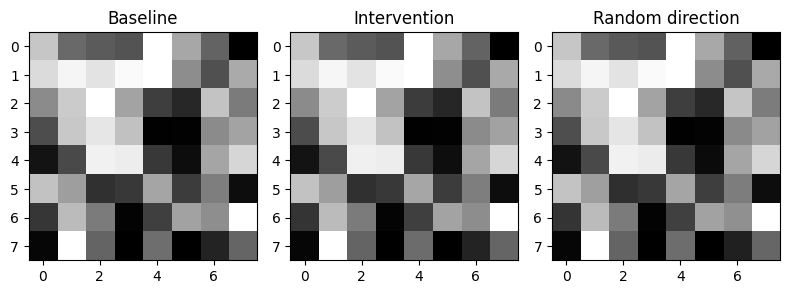

Noise training loss: 0.5815731287002563
Intervention vs baseline RMS: 0.00364304450340569


In [2]:
from diffusers import UNet2DModel, DDPMScheduler
from autoexplain.diffusion import sample_diffusers, diffusion_intervention
import matplotlib.pyplot as plt
net = UNet2DModel(sample_size=8, in_channels=1, out_channels=1, layers_per_block=1,
    block_out_channels=(8,), down_block_types=("DownBlock2D",), up_block_types=("UpBlock2D",),
    norm_num_groups=4, add_attention=False)
data = torch.full((8,1,8,8), -1.)
data[:4,:,:,3:5] = 1.; data[4:,:,3:5,:] = 1.
schedule = DDPMScheduler(num_train_timesteps=20)
optimizer = torch.optim.Adam(net.parameters(),lr=.003)
for _ in range(20):
    noise = torch.randn_like(data); t = torch.randint(0,20,(8,))
    noisy = schedule.add_noise(data,noise,t)
    loss = (net(noisy,t).sample-noise).square().mean()
    optimizer.zero_grad(); loss.backward(); optimizer.step()
initial = torch.randn(1,1,8,8)
def scheduler(): return DDPMScheduler(num_train_timesteps=20)
baseline = sample_diffusers(net,scheduler(),initial,steps=6,seed=7)
zero = sample_diffusers(net,scheduler(),initial,steps=6,seed=7,active_steps=[2,3],
    intervention=lambda:diffusion_intervention(net,"conv_in",torch.ones(8),strength=0))
assert torch.equal(baseline,zero)
changed = sample_diffusers(net,scheduler(),initial,steps=6,seed=7,active_steps=[2,3],
    intervention=lambda:diffusion_intervention(net,"conv_in",torch.ones(8),strength=.3))
random_direction = torch.randn(8)
control = sample_diffusers(net,scheduler(),initial,steps=6,seed=7,active_steps=[2,3],
    intervention=lambda:diffusion_intervention(net,"conv_in",random_direction,strength=.3))
fig,axes=plt.subplots(1,3,figsize=(8,3))
for ax,image,title in zip(axes,[baseline,changed,control],["Baseline","Intervention","Random direction"]):
    ax.imshow(image[0,0],cmap="gray",vmin=-1,vmax=1);ax.set_title(title)
plt.tight_layout();plt.show()
print("Noise training loss:",float(loss.detach()))
print("Intervention vs baseline RMS:",float((changed-baseline).square().mean().sqrt()))


In [3]:
elapsed = time.perf_counter() - started
rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
rss_mib = rss / (1024**2 if sys.platform == "darwin" else 1024)
print(json.dumps({"tutorial_compute_wall_seconds": round(elapsed, 3),
                 "kernel_lifetime_peak_rss_mib": round(rss_mib, 2),
                 "memory_scope": "kernel only, including imports; not aggregate system memory"}))


{"tutorial_compute_wall_seconds": 5.748, "kernel_lifetime_peak_rss_mib": 700.34, "memory_scope": "kernel only, including imports; not aggregate system memory"}
